```{index} single: solver; cvxpy
```
```{index} single: solver; highs
```

# Extra material: Refinery production and shadow pricing with CVXPY

This is a simple linear optimization problem in six variables, but with four equality constraints it allows for a graphical explanation of some unusually large shadow prices for manufacturing capacity. The notebook presents also contrasts Pyomo with CVXPY modeling.

## Preamble: Install Pyomo and a solver

The following cell sets and verifies a global SOLVER for the notebook. If run on Google Colab, the cell installs Pyomo and the HiGHS solver, while, if run elsewhere, it assumes Pyomo and HiGHS have been previously installed. It then sets to use HiGHS as solver via the appsi module and a test is performed to verify that it is available. The solver interface is stored in a global object `SOLVER` for later use. The comparison below also uses CVXPY; install it locally with `%pip install cvxpy` if needed.

In [1]:
import sys
 
if 'google.colab' in sys.modules:
    %pip install pyomo >/dev/null 2>/dev/null
    %pip install highspy >/dev/null 2>/dev/null
 
solver = 'appsi_highs'

import pyomo.environ as pyo
SOLVER = pyo.SolverFactory(solver)

assert SOLVER.available(), f"Solver {solver} is not available."

In [2]:
if 'google.colab' in sys.modules:
    %pip install -q cvxpy

This example derived from Example 19.3 from Seborg, Edgar, Mellichamp, and Doyle. 

> Seborg, Dale E., Thomas F. Edgar, Duncan A. Mellichamp, and Francis J. Doyle III. Process dynamics and control. John Wiley & Sons, 2016.

The changes include updating prices, new solutions using optimization modeling languages, adding constraints, and adjusting parameter values to demonstrate the significance of duals and their interpretation as shadow prices.

## Problem data

In [3]:
import numpy as np
import cvxpy as cp
import pandas as pd

products = pd.DataFrame(
    {
        "gasoline": {"capacity": 24000, "price": 108},
        "kerosine": {"capacity": 2000, "price": 72},
        "fuel oil": {"capacity": 6000, "price": 63},
        "residual": {"capacity": 2500, "price": 30},
    }
).T

crudes = pd.DataFrame(
    {
        "crude 1": {"available": 28000, "price": 72, "process cost": 1.5},
        "crude 2": {"available": 15000, "price": 45, "process cost": 3},
    }
).T

# note: volumetric yields may not add to 100%
yields = pd.DataFrame(
    {
        "crude 1": {"gasoline": 80, "kerosine": 5, "fuel oil": 10, "residual": 5},
        "crude 2": {"gasoline": 44, "kerosine": 10, "fuel oil": 36, "residual": 10},
    }
).T

display(products)
display(crudes)
display(yields)

,capacity,price
gasoline,24000,108
kerosine,2000,72
fuel oil,6000,63
residual,2500,30


,available,price,process cost
crude 1,28000.0,72.0,1.5
crude 2,15000.0,45.0,3.0


,gasoline,kerosine,fuel oil,residual
crude 1,80,5,10,5
crude 2,44,10,36,10


## Pyomo Model

In [4]:
m = pyo.ConcreteModel()

m.CRUDES = pyo.Set(initialize=crudes.index)
m.PRODUCTS = pyo.Set(initialize=products.index)

# decision variables
m.x = pyo.Var(m.CRUDES, domain=pyo.NonNegativeReals)
m.y = pyo.Var(m.PRODUCTS, domain=pyo.NonNegativeReals)


# objective
@m.Expression()
def revenue(m):
    return sum(products.loc[p, "price"] * m.y[p] for p in m.PRODUCTS)


@m.Expression()
def feed_cost(m):
    return sum(crudes.loc[c, "price"] * m.x[c] for c in m.CRUDES)


@m.Expression()
def process_cost(m):
    return sum(crudes.loc[c, "process cost"] * m.x[c] for c in m.CRUDES)


@m.Objective(sense=pyo.maximize)
def profit(m):
    return m.revenue - m.feed_cost - m.process_cost


# constraints
@m.Constraint(m.PRODUCTS)
def balances(m, p):
    return m.y[p] == sum(yields.loc[c, p] * m.x[c] for c in m.CRUDES) / 100


@m.Constraint(m.CRUDES)
def feeds(m, c):
    return m.x[c] <= crudes.loc[c, "available"]


@m.Constraint(m.PRODUCTS)
def capacity(m, p):
    return m.y[p] <= products.loc[p, "capacity"]


results = SOLVER.solve(m)
pyo.assert_optimal_termination(results)
print(round(m.profit(), 3))

860275.862


## CVXPY Model

The `CVXPY` library for disciplined convex optimization is tightly integrated with `numpy`, the standard Python library for the numerical linear algebra. For example, where `Pyomo` uses explicit indexing in constraints, summations, and other objects, `CVXPY` uses the implicit indexing implied when doing matrix and vector operations. 

Another sharp contrast with `Pyomo` is that `CXVPY` has no specific object to describe a set,or to define a objects variables or other modeling objects over arbitrary sets. `CVXPY` instead uses the zero-based indexing familiar to Python users. 

The following cell demonstrates these differences by presenting a `CVXPY` model for the small refinery example. Both implementations use the open-source HiGHS solver installed in the preamble. 

In [5]:
# decision variables
x = cp.Variable(len(crudes.index), pos=True, name="crudes")
y = cp.Variable(len(products.index), pos=True, name="products")

# objective
revenue = products["price"].to_numpy().T @ y
feed_cost = crudes["price"].to_numpy().T @ x
process_cost = crudes["process cost"].to_numpy().T @ x
profit = revenue - feed_cost - process_cost
objective = cp.Maximize(profit)

# constraints
balances = y == yields.to_numpy().T @ x / 100
feeds = x <= crudes["available"].to_numpy()
capacity = y <= products["capacity"].to_numpy()
constraints = [balances, feeds, capacity]

# solution
problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.HIGHS)
if problem.status != cp.OPTIMAL:
    raise RuntimeError(f"CVXPY solve did not terminate optimally: {problem.status}")
problem.value

np.float64(860275.8620689656)

## Crude oil feed results

In [6]:
results_crudes = crudes.copy()
results_crudes["consumption"] = x.value
results_crudes["shadow price"] = feeds.dual_value

display(results_crudes.round(1))

,available,price,process cost,consumption,shadow price
crude 1,28000.0,72.0,1.5,26206.9,0.0
crude 2,15000.0,45.0,3.0,6896.6,0.0


## Refinery production results

In [7]:
results_products = products.copy()
results_products["production"] = y.value
results_products["unused capacity"] = products["capacity"] - y.value
results_products["shadow price"] = capacity.dual_value

display(results_products.round(1))

,capacity,price,production,unused capacity,shadow price
gasoline,24000,108,24000.0,0.0,14.0
kerosine,2000,72,2000.0,0.0,262.6
fuel oil,6000,63,5103.4,896.6,0.0
residual,2500,30,2000.0,500.0,0.0


## Why is the shadow price of kerosine so high?

(0.0, 24000.0)

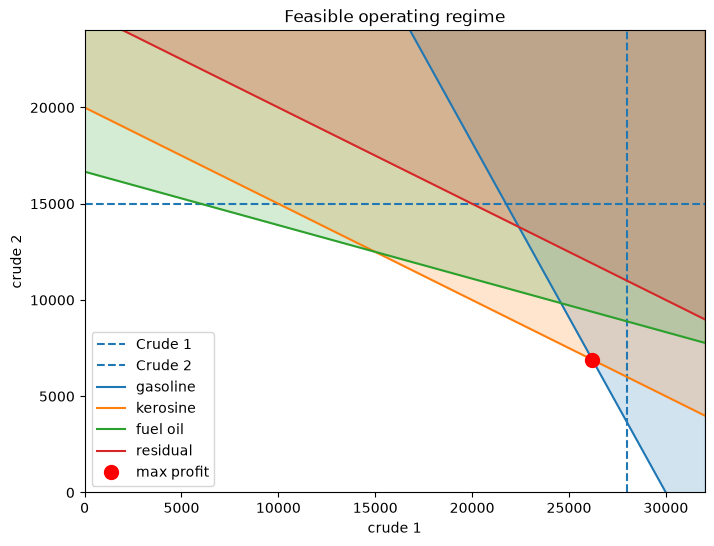

In [8]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6))
ylim = 24000
xlim = 32000

ax.axvline(crudes.loc["crude 1", "available"], linestyle="--", label="Crude 1")
ax.axhline(crudes.loc["crude 2", "available"], linestyle="--", label="Crude 2")

xplot = np.linspace(0, xlim)
for product in products.index:
    b = 100 * products.loc[product, "capacity"] / yields.loc["crude 2", product]
    slope = -yields.loc["crude 1", product] / yields.loc["crude 2", product]
    line = ax.plot(xplot, slope * xplot + b, label=product)
    ax.fill_between(xplot, slope * xplot + b, 30000, color=line[0].get_color(), alpha=0.2)

ax.plot(x.value[0], x.value[1], "ro", ms=10, label="max profit")
ax.set_title("Feasible operating regime")
ax.set_xlabel(crudes.index[0])
ax.set_ylabel(crudes.index[1])
ax.legend()
ax.set_xlim(0, xlim)
ax.set_ylim(0, ylim)

## Suggested Exercises

1. Suppose the refinery makes a substantial investment to double kerosene production in order to increase profits. What becomes the limiting constraint?

2. How do prices of crude oil and refinery products change the location of the optimum operating point?

2. A refinery is a financial asset for the conversion of commodity crude oils into commodity hydrocarbons. What economic value can be assigned to owning the option to convert crude oils into other commodities?